# PasDB
This turtorial presents how to use PAS objects for defect parameter calculations.\
the pas objects defined are PASdb and PAScdb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspectrum import Spectrum, Peak, FindPeaksDomain, germanium_fwhm, TimeChannelParser
from pyPAS.pas_db import PASdb, PAScdb
from pyPAS.coincidence_events_filter import PasCoincidenceFilter
from uncertainties import ufloat, nominal_value, std_dev

# PASdb example

In [2]:
# load data file (time stamps and channel)
file = '../libs/PASdb/db_spectrum'
# detector parameters
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
energy_resolution_det = 1.05 
estimated_FWHM_det = lambda energy: germanium_fwhm(energy, 0, energy_resolution_det/511**0.5, 0)

In [3]:
# in dataframe format
data_df = pd.read_csv(file, names =['channel', 'counts'], sep='\t', skiprows=1)

In [4]:
# defined db
db = PASdb.from_dataframe(data_df, energy_calib_poly, estimated_FWHM_det)
# The peak can be centrlized to 511 [keV] (due to detector shift from center)
db.centralize_annihilation_peak()

In [5]:
# calculate lineshpe parameters
energy_domain_s = [510.2, 511.8]         # Region B (S parameter)
energy_domain_w_l = [507.8, 509.3]         # Region A or C (left)
energy_domain_w_r = [512.7, 514.8]         # Region A or C (right)
total_energy_domain = [507.7, 514.9]
db.s_parameter_calculation(total_energy_domain, energy_domain_s), db.w_parameter_calculation(total_energy_domain, energy_domain_w_l, energy_domain_w_r)

(0.48933512111741045+/-0.0007012983363179661,
 0.1591106250130734+/-0.0004907817973618635)

# PAScdb example

first we load the data with the right parameters

In [6]:
# the data files from the detector (time stamps and channel)
file_1 = '../libs/cu_sample_500/detector_0/5000eV_ch000.txt'
file_2 = '../libs/cu_sample_500/detector_1/5000eV_ch001.txt'
# defnitions from the calibration

energy_calib_poly_det_1 = np.poly1d([0.0408976444, 0.0822321508])
energy_calib_poly_det_2 = np.poly1d([0.0418921521, 0.0653720462])

energy_resolution_det_1 = 1.05 
energy_resolution_det_2 = 1.08 
estimated_FWHM_det_1 = lambda energy: germanium_fwhm(energy, 0, energy_resolution_det_1/511**0.5, 0)
estimated_FWHM_det_2 = lambda energy: germanium_fwhm(energy, 0, energy_resolution_det_2/511**0.5, 0)



we want to recalibratethe energy because the center should be at 511 keV

In [7]:
data_detector_1 = pd.read_csv(file_1, skiprows=5, sep=' ', names=['time', 'channel', 'flag'], usecols=range(3))
spectrum_detector_1 = TimeChannelParser.to_spectrum(data_detector_1, energy_calib_poly_det_1, estimated_FWHM_det_1)
db_detector_1 = PASdb.from_spectrum(spectrum_detector_1)

data_detector_2 = pd.read_csv(file_2, skiprows=5, sep=' ', names=['time', 'channel', 'flag'], usecols=range(3))
spectrum_detector_2 = TimeChannelParser.to_spectrum(data_detector_2, energy_calib_poly_det_2, estimated_FWHM_det_2)
db_detector_2 = PASdb.from_spectrum(spectrum_detector_2)

# recalibrate
calibration_correction_detector_1 = nominal_value(db_detector_1.first_moment_method_center())- 511
calibration_correction_detector_2 = nominal_value(db_detector_2.first_moment_method_center())- 511

energy_calib_poly_det_1 = np.poly1d([0.0408976444, 0.0822321508 - calibration_correction_detector_1])
energy_calib_poly_det_2 = np.poly1d([0.0418921521, 0.0653720462 - calibration_correction_detector_2])

with the new calibration,  filter the cdb

In [8]:
time_cdb_pairs = PasCoincidenceFilter.time_coincidence_filter(data_detector_1, data_detector_2,max_time_interval=10)

In [9]:
cdb_pairs = PasCoincidenceFilter.energy_coincidence_filter(time_cdb_pairs, energy_calibration_poly_1=energy_calib_poly_det_1, energy_calibration_poly_2=energy_calib_poly_det_2,
                                               fwhm_1=energy_resolution_det_1, fwhm_2=energy_resolution_det_2, number_of_cdb_sigma=2)

In [10]:
cdb = PAScdb(cdb_pairs)

Text(0.5, 1.0, 'cdb of Cu (annealed to 500 degrees) measurement')

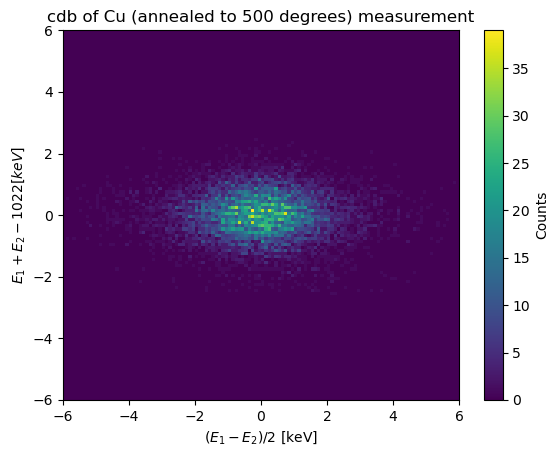

In [11]:
coincidence_map = cdb.coincidence_map([-6, 6], mesh_interval=0.1)

coincidence_map.plot(cbar_kwargs={'label': 'Counts'})
plt.xlabel('$(E_1 - E_2)/2$ [keV]')
plt.ylabel('$E_1 + E_2 - 1022 [keV]$')
plt.title('cdb of Cu (annealed to 500 degrees) measurement')


The db and resolution.
Notice the momentum distribution and how it opens in the high momenta, also note the resolution background (in some cases it's stronger)

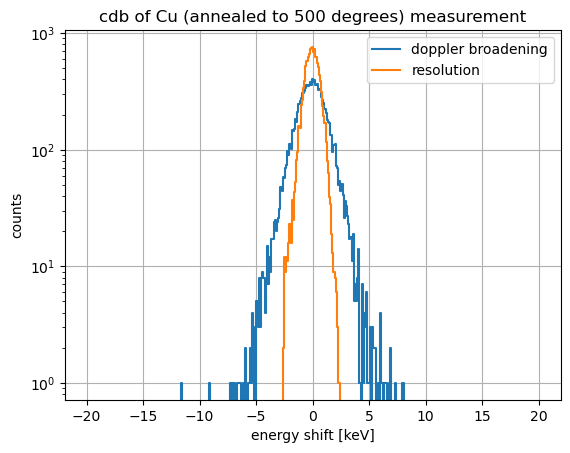

In [12]:
db_cdb = cdb.doppler_broadening_spectrum([-20,20], 0.1)
res_cdb = cdb.resolution_spectrum([-20,20], 0.1)
db_cdb.plot.step(yscale='log', label='doppler broadening')
res_cdb.plot.step(yscale='log', label='resolution')
plt.ylabel('counts')
plt.xlabel('energy shift [keV]')
plt.title('cdb of Cu (annealed to 500 degrees) measurement')
plt.legend()
plt.grid(True)